In [34]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, recall_score, roc_auc_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from IPython.display import display

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

#### Nesse notebook, geraremos um modelo simplificado, sem GridSearch, sem StratifiedKFold, apenas pra gerar nossa primeira pravisão e submissão, e avaliar o progresso do nosso modelo ao longo do percurso.

In [8]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X=X.copy()
        X['log_MonthlyCharges'] = np.log1p(df['MonthlyCharges'])
        return X

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   id                594194 non-null  int64   
 1   gender            594194 non-null  category
 2   SeniorCitizen     594194 non-null  category
 3   Partner           594194 non-null  category
 4   Dependents        594194 non-null  category
 5   tenure            594194 non-null  int64   
 6   PhoneService      594194 non-null  category
 7   MultipleLines     594194 non-null  category
 8   InternetService   594194 non-null  category
 9   OnlineSecurity    594194 non-null  category
 10  OnlineBackup      594194 non-null  category
 11  DeviceProtection  594194 non-null  category
 12  TechSupport       594194 non-null  category
 13  StreamingTV       594194 non-null  category
 14  StreamingMovies   594194 non-null  category
 15  Contract          594194 non-null  category
 16  Pa

In [45]:
df = joblib.load('df_att.pkl')

index = df['id']

target = 'Churn'

X = df.drop([target, 'id'], axis=1)
y = df[target]

In [64]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45


In [4]:
def extract_xy(df):
    target = 'Churn'
    X = df.drop([target, 'id'], axis=1)
    y = df[target]
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

    return X_train, X_val, y_train, y_val



In [5]:
X_train, X_val, y_train, y_val = extract_xy(df)

cat_features = X_train.select_dtypes(exclude='number').columns.tolist()
num_features = X_train.select_dtypes(include='number').columns.tolist()

In [9]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,log_MonthlyCharges
582467,Male,0,No,No,56,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.50,5514.95,4.620059
287479,Male,0,No,No,1,Yes,Yes,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,54.55,54.55,4.017284
140287,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),115.65,7782.85,4.759178
265225,Male,0,Yes,No,17,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.80,337.90,3.034953
146500,Male,0,No,No,66,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,109.20,6603.00,4.702297


In [29]:
model = CatBoostClassifier(iterations = 200, learning_rate=0.6, depth=6, l2_leaf_reg=1.2, border_count=150, eval_metric='AUC', cat_features=cat_features, verbose=100)

In [30]:
pipe = Pipeline([
    ('fe', FeatureEngineer()),
    ('model', model)
])

In [31]:
pipe.fit(X_train, y_train)


0:	total: 389ms	remaining: 1m 17s
100:	total: 34.9s	remaining: 34.2s
199:	total: 1m 10s	remaining: 0us


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('fe', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False


In [38]:
pred = pipe.predict(X_val)

score = roc_auc_score(y_val, pred)
score

0.7844358544915848

In [40]:
pipe.named_steps['model'].feature_importances_

array([ 0.17713706,  1.39229662,  0.18504298,  0.86399375, 31.25952549,
        1.36094657,  1.11251066,  0.82536033,  2.43169525,  0.58196705,
        0.75044367,  1.81315086,  0.45420129,  0.40028036, 16.87009674,
        7.40644057,  6.55758661,  5.02114993,  6.03929633, 14.49687788])

In [43]:
X_train_fe.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'log_MonthlyCharges'],
      dtype='object')

In [46]:
pipe.fit(X, y)

0:	total: 699ms	remaining: 2m 19s
100:	total: 47.2s	remaining: 46.3s
199:	total: 1m 30s	remaining: 0us


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('fe', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False


In [68]:
test = joblib.load('test_att.pkl')
index = test['id']
test = test.drop('id', axis=1)

In [69]:


test_fe = pipe.named_steps['fe'].transform(test)

In [71]:
test_predict = model.predict_proba(test_fe)[:,1]
test_predict

array([0.02082447, 0.00189225, 0.12017262, ..., 0.06863487, 0.02891079,
       0.39493694], shape=(254655,))

In [72]:
df_test = pd.DataFrame({'id': index, 'Churn': test_predict})

df_test.head(3)

,id,Churn
0,594194,0.020824
1,594195,0.001892
2,594196,0.120173


In [73]:
df_test.to_csv('1.1_submission.csv', index=False)


In [41]:
predict = model.predict(X_val)


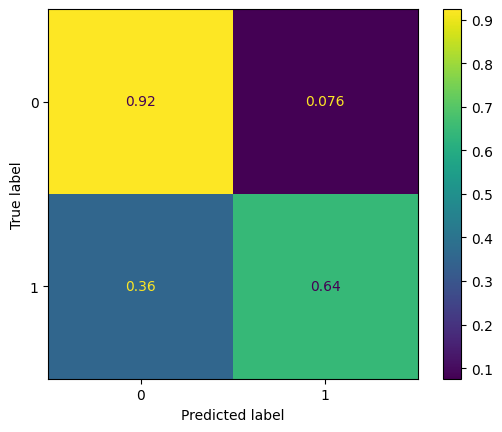

In [44]:
ConfusionMatrixDisplay.from_predictions(y_val, predict, normalize='true')

In [47]:
recall = recall_score(y_val, predict)

In [48]:
recall

0.6426426426426426